In [6]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
os.makedirs('images', exist_ok=True)

# 글로벌 금융주 포트폴리오 (해외 은행 면접용)
tickers = {
    'JPM': 'JP Morgan',
    'GS': 'Goldman Sachs',
    'AAPL': 'Apple',
    'MSFT': 'Microsoft',
    'GOOGL': 'Google',
    'BRK-B': 'Berkshire Hathaway',
    'JNJ': 'Johnson & Johnson',
    'XOM': 'Exxon Mobil'
}

# 5년치 데이터 수집
df = yf.download(list(tickers.keys()), start='2020-01-01', end='2024-12-31')['Close']
df.columns = [tickers[col] for col in df.columns]

print(f"데이터 크기: {df.shape}")
print(f"기간: {df.index[0].date()} ~ {df.index[-1].date()}")
df.tail()

[*********************100%***********************]  8 of 8 completed

데이터 크기: (1257, 8)
기간: 2020-01-02 ~ 2024-12-30


,Apple,Berkshire Hathaway,Google,Goldman Sachs,Johnson & Johnson,JP Morgan,Microsoft,Exxon Mobil
Date,,,,,,,,
2024-12-23,253.883118,454.350006,193.734344,556.436096,140.209885,232.399841,431.078857,101.857849
2024-12-24,256.797180,458.660004,195.207535,568.144226,140.769684,236.221344,435.119751,101.953659
2024-12-26,257.612701,459.079987,194.699890,566.623352,140.509094,237.030502,433.911407,102.039902
2024-12-27,254.201355,456.510010,191.872925,561.700195,139.997559,235.109985,426.404083,102.030327
2024-12-30,250.829773,452.160004,190.359940,559.136353,138.347107,233.306488,420.758698,101.340416


In [7]:
print("결측치 확인:")
print(df.isnull().sum())
df = df.fillna(method='ffill')
print("\n결측치 처리 완료!")

결측치 확인:
Apple                 0
Berkshire Hathaway    0
Google                0
Goldman Sachs         0
Johnson & Johnson     0
JP Morgan             0
Microsoft             0
Exxon Mobil           0
dtype: int64

결측치 처리 완료!


C:\Users\playdata2\AppData\Local\Temp\ipykernel_22332\942310343.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


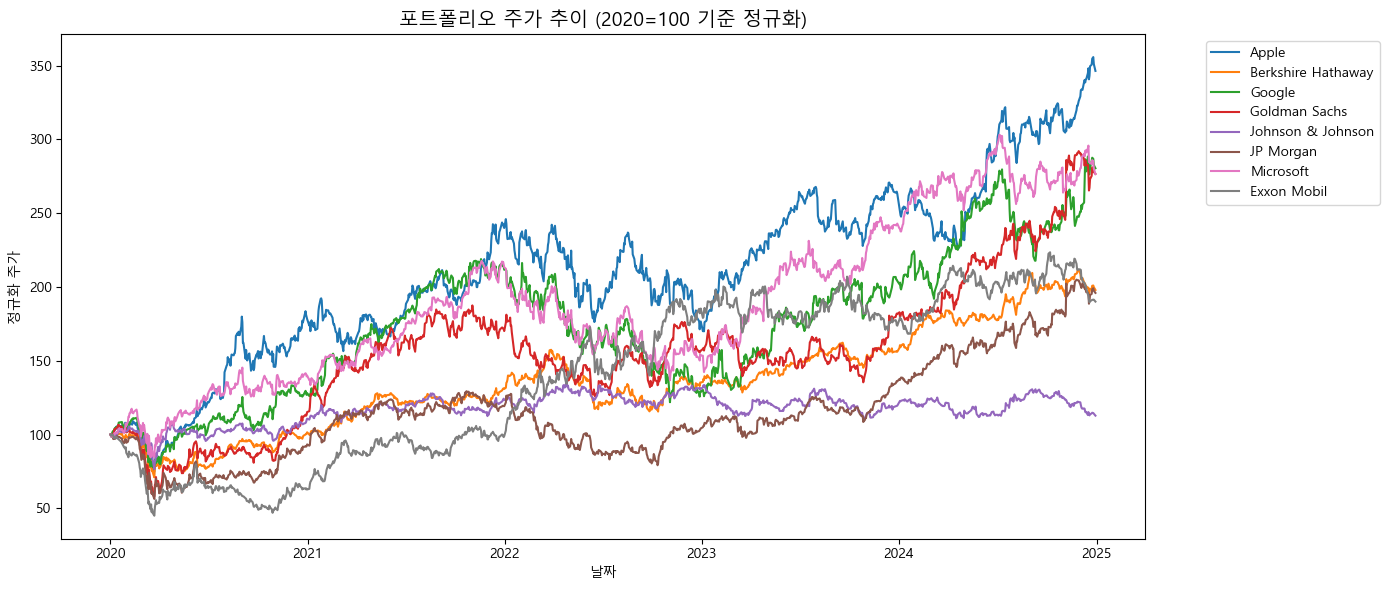

In [8]:
normalized = df / df.iloc[0] * 100

plt.figure(figsize=(14, 6))
for col in normalized.columns:
    plt.plot(normalized.index, normalized[col], label=col, linewidth=1.5)

plt.title('포트폴리오 주가 추이 (2020=100 기준 정규화)', fontsize=14)
plt.xlabel('날짜')
plt.ylabel('정규화 주가')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('images/price_trend.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
returns = df.pct_change().dropna()

print("=== 연간 수익률 ===")
annual_returns = returns.mean() * 252
print(annual_returns.sort_values(ascending=False).round(4))

print("\n=== 연간 변동성 (리스크) ===")
annual_vol = returns.std() * np.sqrt(252)
print(annual_vol.sort_values(ascending=False).round(4))

=== 연간 수익률 ===
Apple                 0.2995
Google                0.2598
Goldman Sachs         0.2589
Microsoft             0.2507
Exxon Mobil           0.1880
JP Morgan             0.1878
Berkshire Hathaway    0.1607
Johnson & Johnson     0.0434
dtype: float64

=== 연간 변동성 (리스크) ===
Exxon Mobil           0.3439
Goldman Sachs         0.3313
JP Morgan             0.3254
Google                0.3251
Apple                 0.3169
Microsoft             0.3051
Berkshire Hathaway    0.2175
Johnson & Johnson     0.1966
dtype: float64


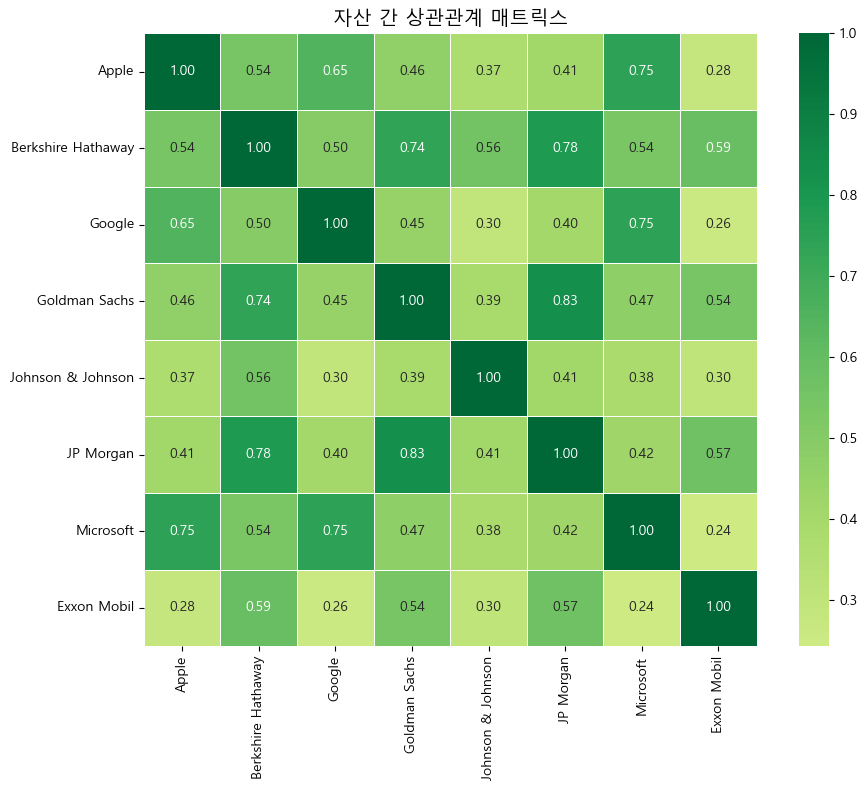

In [10]:
plt.figure(figsize=(10, 8))
corr = returns.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5)
plt.title('자산 간 상관관계 매트릭스', fontsize=14)
plt.tight_layout()
plt.savefig('images/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()